<a href="https://colab.research.google.com/github/myla48/Sample---Superstore/blob/main/Superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title & Introduction

Superstore Data Analysis Project

 Objective
Analyze the Superstore dataset using Pandas:
- Data exploration
- Data cleaning
- Feature engineering
- Aggregation & grouping
- Visualization
- Insights

---

Install & Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task 1: Load & Explore Data

In [39]:
# Load dataset
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

# View first rows
df.head()

# Dataset info
df.info()

# Summary statistics
df.describe()

# Columns
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Task 2: Data Cleaning

In [40]:
# Check missing values
df.isnull().sum()

# Drop or fill missing values
df = df.dropna()  # or use fillna()

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Task 3: Feature Engineering

In [41]:
# Extract Year & Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Create Profit Ratio
df['Profit Ratio'] = df['Profit'] / df['Sales']

# Verify
df[['Sales', 'Profit', 'Profit Ratio']].head()

,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


Task 4: GroupBy & Aggregation

Total Sales by Category

In [42]:
sales_by_category = df.groupby('Category')['Sales'].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


Total Profit by Region

In [43]:
profit_by_region = df.groupby('Region')['Profit'].sum()
print(profit_by_region)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


Top 5 Customers

In [44]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


Monthly Sales Trend

In [45]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
print(monthly_sales)

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

Task 5: Pivot Tables

In [46]:
# Sales by Category & Region
pivot1 = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')

# Sales trends by Segment
pivot2 = pd.pivot_table(df, values='Sales', index='Month', columns='Segment', aggfunc='sum')

# Profit by Sub-Category
pivot3 = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')

print(pivot1)
print(pivot2)
print(pivot3)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320
Segment     Consumer    Corporate  Home Office
Month                                         
1         50441.2906   26790.3480   17693.1970
2         33826.1760   14575.0670   11350.0084
3         89174.7070   58239.9132   57590.8686
4         54845.1895   49233.1636   33683.7755
5         86932.7144   47289.0323   20807.0650
6         82910.1803   40858.5370   28949.9620
7         81769.7730   46919.2060   18549.1180
8         82319.8063   57529.4477   19194.8090
9        185055.9196   74020.2213   48573.8048
10        66713.0877   78291.7600   55318.1370
11       170958.7383  119431.3957   62070.9370
12       176453.7623   92968.2750   55871.4662
            

Task 6: Data Splitting & Merging

In [47]:
# Split dataset
df_sales = df[['Order ID', 'Sales', 'Customer Name']]
df_profit = df[['Order ID', 'Profit']]

# Merge back
merged_df = pd.merge(df_sales, df_profit, on='Order ID')

merged_df.head()

,Order ID,Sales,Customer Name,Profit
0,CA-2016-152156,261.96,Claire Gute,41.9136
1,CA-2016-152156,261.96,Claire Gute,219.5820
2,CA-2016-152156,731.94,Claire Gute,41.9136
3,CA-2016-152156,731.94,Claire Gute,219.5820
4,CA-2016-138688,14.62,Darrin Van Huff,6.8714


Task 7: Data Visualization

 Line Chart - Sales Trend

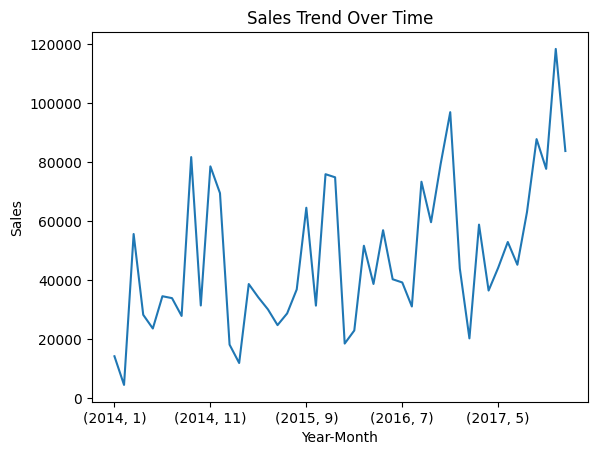

In [48]:
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.show()

Bar Chart (Sales by Category)

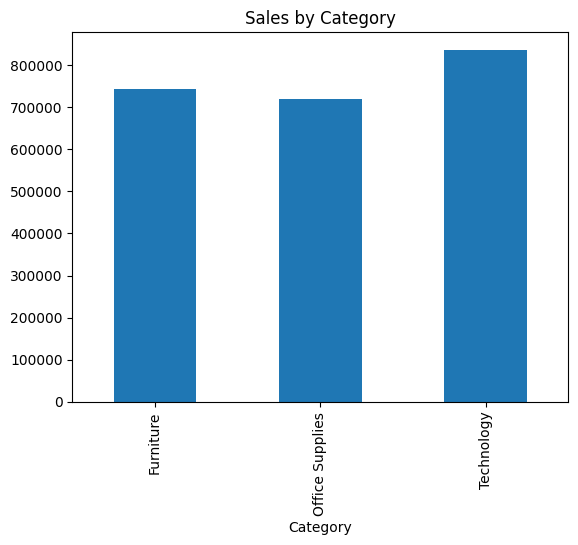

In [49]:
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

Bar Chart (Profit by Region)

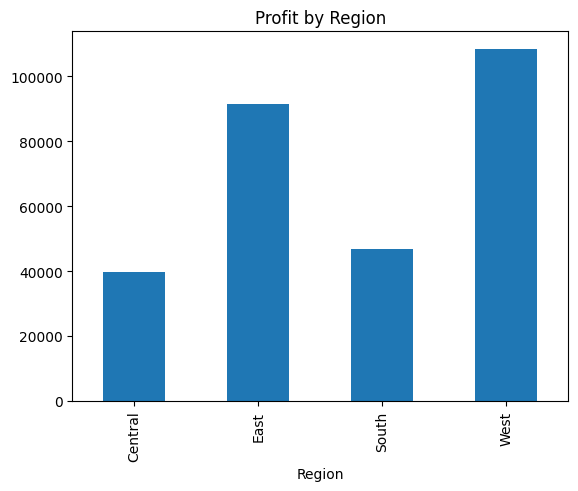

In [50]:
profit_by_region.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

Pie Chart (Segment Distribution)

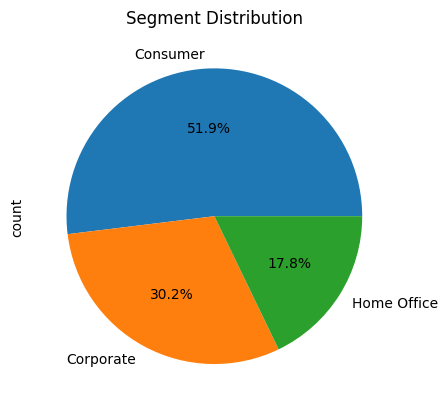

In [51]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.show()

Task 8: Insights

In [52]:
# Most profitable category
most_profitable_category = df.groupby('Category')['Profit'].sum().idxmax()
print("Most Profitable Category:", most_profitable_category)

# Least performing region
least_region = df.groupby('Region')['Profit'].sum().idxmin()
print("Least Performing Region:", least_region)

Most Profitable Category: Technology
Least Performing Region: Central


Final Insights

Key Insights

- The most profitable category is: (output above)
- The least performing region is: (output above)

Observations:
- Some regions generate high sales but low profit
- Profit ratio varies significantly across categories
- Sales show trends over time (seasonal patterns)

 Conclusion:
This dataset shows that high sales do not always mean high profit. Strategic decisions should focus on profitability, not just revenue.